# Health Data Quality Assessment - Walkthrough

This notebook demonstrates the complete Data Quality Assessment (DQA) pipeline for routine health facility reports in Nigeria.

## Contents
1. Setup and Data Generation
2. Load and Explore Data
3. Quality Checks (Step-by-Step)
4. Scoring and Metrics
5. Visualizations
6. Summary and Recommendations

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path
import subprocess, sys

# Add src to path
sys.path.insert(0, '../')

from src.quality import rules, metrics
from src.utils import io, dates

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Create figures directory
Path('../reports/figures').mkdir(parents=True, exist_ok=True)

print("✓ Setup complete")

✓ Setup complete


## 1. Setup and Data Generation

First, let's generate synthetic data if it doesn't exist yet.

In [4]:
# Check if data exists, generate if not
reports_path = Path('../data/raw/facility_reports.csv')
registry_path = Path('../data/raw/facility_registry.csv')

if not reports_path.exists() or not registry_path.exists():
    print("Generating synthetic data...")
    subprocess.check_call([sys.executable, "-m", "src.data.generate_synthetic_routine_data", "--facilities", "1200", "--months", "24"])
else:
    print("✓ Data already exists")

✓ Data already exists


## 2. Load and Explore Data

In [5]:
# Load data
print("Loading data...")
registry = pd.read_csv('../data/raw/facility_registry.csv')
reports = pd.read_csv('../data/raw/facility_reports.csv')
config = yaml.safe_load(open('../config/dqa_config.yml', 'r'))

print(f"\n✓ Loaded:")
print(f"  - {len(registry)} facilities")
print(f"  - {len(reports)} facility-month reports")
print(f"  - {reports['period'].nunique()} unique periods")

Loading data...

✓ Loaded:
  - 1200 facilities
  - 28798 facility-month reports
  - 24 unique periods


In [4]:
# Display sample records
print("Sample Facility Registry:")
display(registry.head())

print("\nSample Facility Reports:")
display(reports.head())

Sample Facility Registry:


,facility_id,facility_name,state,lga,facility_type,ownership,latitude,longitude
0,FAC00001,Abia PHC 1,Abia,Abia East,PHC,Private,11.796910,10.162202
1,FAC00002,Abia PHC 2,Abia,Abia East,PHC,Public,12.661761,10.213380
2,FAC00003,Abia PHC 3,Abia,Abia South,PHC,Public,11.219988,14.262633
3,FAC00004,Abia PHC 4,Abia,Abia North,PHC,Private,7.042422,9.297077
4,FAC00005,Abia PHC 5,Abia,Abia East,PHC,Public,7.998610,3.559988



Sample Facility Reports:


,facility_id,period,opd_visits,anc1_first_visit,anc4_visits,facility_deliveries,bcg_doses,penta1_doses,penta3_doses,measles1_doses,fully_immunized_under1,vaccine_stockout_days,eligible_under1_population,submission_date
0,FAC00001,2024-01,8098.0,482.0,166.0,110.0,125.0,87.0,27.0,21.0,17.0,3,382,2024-02-05
1,FAC00001,2024-02,7442.0,443.0,260.0,187.0,115.0,80.0,NaN,20.0,15.0,1,386,2024-03-11
2,FAC00001,2024-03,6494.0,386.0,432.0,72.0,100.0,70.0,20.0,19.0,13.0,3,369,2024-04-03
3,FAC00001,2024-04,7460.0,444.0,224.0,151.0,115.0,80.0,NaN,19.0,15.0,1,374,2024-05-05
4,FAC00001,2024-05,9188.0,547.0,372.0,280.0,142.0,99.0,28.0,24.0,18.0,4,362,2024-06-13


In [6]:
# Basic statistics
print("Facility Distribution by State:")
state_counts = registry['state'].value_counts().sort_index()
print(state_counts)

print(f"\nFacility Types:")
print(registry['facility_type'].value_counts())

print(f"\nOwnership:")
print(registry['ownership'].value_counts())

Facility Distribution by State:
state
Abia           33
Adamawa        33
Akwa Ibom      33
Anambra        33
Bauchi         33
Bayelsa        33
Benue          33
Borno          33
Cross River    33
Delta          33
Ebonyi         33
Edo            33
Ekiti          33
Enugu          33
FCT Abuja      32
Gombe          33
Imo            33
Jigawa         32
Kaduna         32
Kano           32
Katsina        32
Kebbi          32
Kogi           32
Kwara          32
Lagos          32
Nasarawa       32
Niger          32
Ogun           32
Ondo           32
Osun           32
Oyo            32
Plateau        32
Rivers         32
Sokoto         32
Taraba         32
Yobe           32
Zamfara        32
Name: count, dtype: int64

Facility Types:
facility_type
PHC                 940
General Hospital    260
Name: count, dtype: int64

Ownership:
ownership
Public     1026
Private     174
Name: count, dtype: int64


## 3. Quality Checks (Step-by-Step)

Now let's run each quality check and examine the results.

### 3.1 Completeness Check

In [7]:
# Merge reports with registry for state information
reports_merged = reports.merge(registry[['facility_id', 'state', 'facility_type']], 
                               on='facility_id', how='left')

# Check completeness
completeness_results = rules.check_completeness(
    reports_merged, 
    config['essential_columns'],
    threshold=config['thresholds']['completeness_min']
)

print("Completeness Check Results:")
print(f"  - Total records checked: {len(completeness_results)}")
print(f"  - Records flagged incomplete: {completeness_results['flag_incomplete'].sum()}")
print(f"  - Average completeness rate: {completeness_results['completeness_rate'].mean():.2%}")

print("\nSample incomplete records:")
display(completeness_results[completeness_results['flag_incomplete'] == True].head())

Completeness Check Results:
  - Total records checked: 28262
  - Records flagged incomplete: 10420
  - Average completeness rate: 95.94%

Sample incomplete records:


,facility_id,period,check_name,completeness_rate,missing_count,total_fields,flag_incomplete
1,FAC00001,2024-02,completeness,0.909091,1,11,True
3,FAC00001,2024-04,completeness,0.909091,1,11,True
8,FAC00001,2024-09,completeness,0.909091,1,11,True
11,FAC00001,2024-12,completeness,0.909091,1,11,True
12,FAC00001,2025-01,completeness,0.818182,2,11,True


### 3.2 Duplicate Detection

In [8]:
# Check for duplicates
duplicates_results = rules.check_duplicates(reports_merged)

print("Duplicate Detection Results:")
print(f"  - Total facility-months: {len(duplicates_results)}")
print(f"  - Facility-months with duplicates: {duplicates_results['flag_duplicate'].sum()}")
print(f"  - Duplicate rate: {duplicates_results['flag_duplicate'].sum() / len(duplicates_results):.2%}")

print("\nSample duplicate records:")
display(duplicates_results[duplicates_results['flag_duplicate'] == True].head())

Duplicate Detection Results:
  - Total facility-months: 28262
  - Facility-months with duplicates: 536
  - Duplicate rate: 1.90%

Sample duplicate records:


,facility_id,period,check_name,duplicate_count,flag_duplicate
57,FAC00003,2024-10,duplicates,2,True
74,FAC00004,2024-03,duplicates,2,True
157,FAC00007,2025-04,duplicates,2,True
269,FAC00012,2024-12,duplicates,2,True
278,FAC00012,2025-09,duplicates,2,True


### 3.3 Timeliness Check

In [9]:
# Check timeliness
timeliness_results = rules.check_timeliness(
    reports_merged,
    due_days=config['thresholds']['timeliness_due_days']
)

print("Timeliness Check Results:")
print(f"  - Total records: {len(timeliness_results)}")
print(f"  - Records submitted late: {timeliness_results['flag_late'].sum()}")
print(f"  - Late submission rate: {timeliness_results['flag_late'].sum() / len(timeliness_results):.2%}")
print(f"  - Average days late (for late records): {timeliness_results[timeliness_results['flag_late']]['days_late'].mean():.1f}")

print("\nDistribution of days late:")
print(timeliness_results['days_late'].describe())

Timeliness Check Results:
  - Total records: 28262
  - Records submitted late: 20259
  - Late submission rate: 71.68%
  - Average days late (for late records): 9.5

Distribution of days late:
count    28262.000000
mean         5.702250
std          8.205439
min        -30.000000
25%          0.000000
50%          6.000000
75%         11.000000
max         35.000000
Name: days_late, dtype: float64


### 3.4 Outlier Detection

In [11]:
# Get indicator columns
indicator_cols = [col for col in config['essential_columns'] 
                 if col not in ['facility_id', 'period', 'submission_date']]

# Check for outliers
outliers_results = rules.check_outliers(
    reports_merged,
    indicator_cols,
    threshold=config['thresholds']['outliers_mad_threshold']
)

print("Outlier Detection Results:")
print(f"  - Total indicator-observations checked: {len(outliers_results)}")
print(f"  - Outliers detected: {outliers_results['flag_outlier'].sum()}")
print(f"  - Outlier rate: {outliers_results['flag_outlier'].sum() / len(outliers_results):.2%}")

print("\nOutliers by indicator:")
outlier_by_indicator = outliers_results[outliers_results['flag_outlier']].groupby('indicator').size()
print(outlier_by_indicator.sort_values(ascending=False))

print("\nSample outlier records:")
display(outliers_results[outliers_results['flag_outlier'] == True].head())

Outlier Detection Results:
  - Total indicator-observations checked: 303907
  - Outliers detected: 2850
  - Outlier rate: 0.94%

Outliers by indicator:
indicator
fully_immunized_under1    730
measles1_doses            502
facility_deliveries       450
anc4_visits               407
vaccine_stockout_days     315
penta3_doses              138
opd_visits                112
penta1_doses              106
bcg_doses                  87
anc1_first_visit            3
dtype: int64

Sample outlier records:


,facility_id,period,indicator,check_name,value,peer_median,modified_z_score,flag_outlier
332,FAC00015,2025-05,opd_visits,outliers,78910.0,4747.0,22.212675,True
338,FAC00015,2025-11,opd_visits,outliers,19687.0,4747.0,4.474702,True
543,FAC00025,2024-03,opd_visits,outliers,25654.0,4747.0,6.261888,True
548,FAC00025,2024-08,opd_visits,outliers,21150.0,4747.0,4.912888,True
657,FAC00030,2024-09,opd_visits,outliers,27959.0,4747.0,6.952262,True


### 3.5 Spike Detection

In [12]:
# Check for spikes
spikes_results = rules.check_spikes(
    reports_merged,
    indicator_cols,
    pct_change_hi=config['thresholds']['spikes_pct_change_hi'],
    pct_change_lo=config['thresholds']['spikes_pct_change_lo']
)

print("Spike Detection Results:")
print(f"  - Total month-over-month comparisons: {len(spikes_results)}")
print(f"  - Spikes detected: {spikes_results['flag_spike'].sum()}")
print(f"  - Spike rate: {spikes_results['flag_spike'].sum() / len(spikes_results):.2%}")

print("\nSpikes by indicator:")
spike_by_indicator = spikes_results[spikes_results['flag_spike']].groupby('indicator').size()
print(spike_by_indicator.sort_values(ascending=False))

print("\nSample spike records:")
display(spikes_results[spikes_results['flag_spike'] == True].head())

Spike Detection Results:
  - Total month-over-month comparisons: 279774
  - Spikes detected: 12840
  - Spike rate: 4.59%

Spikes by indicator:
indicator
vaccine_stockout_days     8547
anc4_visits               1448
facility_deliveries       1121
penta1_doses               424
opd_visits                 384
bcg_doses                  377
penta3_doses               359
fully_immunized_under1     118
measles1_doses              62
dtype: int64

Sample spike records:


,facility_id,period,indicator,check_name,prev_value,curr_value,pct_change,flag_spike
47,FAC00001,2024-10,anc4_visits,spikes,558.0,273.0,-0.510753,True
61,FAC00001,2024-03,facility_deliveries,spikes,187.0,72.0,-0.614973,True
90,FAC00001,2025-01,bcg_doses,spikes,89.0,11.0,-0.876404,True
91,FAC00001,2025-02,bcg_doses,spikes,11.0,142.0,11.909091,True
104,FAC00001,2024-06,penta1_doses,spikes,99.0,270.0,1.727273,True


### 3.6 Consistency Check

In [13]:
# Check consistency
consistency_results = rules.check_consistency(reports_merged)

print("Consistency Check Results:")
print(f"  - Total records checked: {len(consistency_results)}")
print(f"  - Records with violations: {consistency_results['flag_inconsistent'].sum()}")
print(f"  - Violation rate: {consistency_results['flag_inconsistent'].sum() / len(consistency_results):.2%}")

print("\nViolation counts:")
print(consistency_results['violation_count'].value_counts().sort_index())

print("\nSample violation records:")
display(consistency_results[consistency_results['flag_inconsistent'] == True].head())

Consistency Check Results:
  - Total records checked: 28262
  - Records with violations: 1267
  - Violation rate: 4.48%

Violation counts:
violation_count
0    26995
1     1267
Name: count, dtype: int64

Sample violation records:


,facility_id,period,check_name,violation_count,violations,violation_details,flag_inconsistent
2,FAC00001,2024-03,consistency,1,anc4 should be <= anc1,anc4_visits(432.0) > anc1_first_visit(386.0),True
8,FAC00001,2024-09,consistency,1,anc4 should be <= anc1,anc4_visits(558.0) > anc1_first_visit(439.0),True
58,FAC00003,2024-11,consistency,1,anc4 should be <= anc1,anc4_visits(208.0) > anc1_first_visit(188.0),True
65,FAC00003,2025-06,consistency,1,penta3 should be <= penta1,penta3_doses(323.0) > penta1_doses(295.0),True
133,FAC00006,2025-04,consistency,1,anc4 should be <= anc1,anc4_visits(589.0) > anc1_first_visit(544.0),True


## 4. Scoring and Metrics

Now let's compute quality scores and create summaries.

In [14]:
# Collect all check results
check_results = {
    'completeness': completeness_results,
    'duplicates': duplicates_results,
    'timeliness': timeliness_results,
    'outliers': outliers_results,
    'spikes': spikes_results,
    'consistency': consistency_results
}

# Compute metrics
output_dir = Path('../data/processed')
summaries = metrics.compute_all_metrics(check_results, registry, config, output_dir)

print("✓ Metrics computed and saved")


Computing quality scores...
Creating summaries...
Saving outputs to ../data/processed...
✓ Metrics computation complete
✓ Metrics computed and saved


In [15]:
# Display detailed results sample
detailed = summaries['detailed']
print("Detailed Results (facility-month level):")
display(detailed.head())

print("\nSummary Statistics:")
score_cols = [col for col in detailed.columns if col.endswith('_score')]
print(detailed[score_cols].describe())

Detailed Results (facility-month level):


,facility_id,period,completeness_score,flag_incomplete,duplicates_score,flag_duplicate,timeliness_score,flag_late,outliers_score,spikes_score,consistency_score,flag_inconsistent,overall_score
0,FAC00001,2024-01,100.000000,False,100,False,100.000000,False,100,100.0,100,False,100.000000
1,FAC00001,2024-02,90.909091,True,100,False,71.428571,True,100,75.0,100,False,89.237013
2,FAC00001,2024-03,100.000000,False,100,False,100.000000,False,100,50.0,80,True,89.500000
3,FAC00001,2024-04,90.909091,True,100,False,100.000000,False,100,75.0,100,False,93.522727
4,FAC00001,2024-05,100.000000,False,100,False,57.142857,True,80,75.0,100,False,86.821429



Summary Statistics:
       completeness_score  duplicates_score  timeliness_score  outliers_score  \
count        28262.000000      28262.000000      28262.000000    28262.000000   
mean            95.938652         98.103460         58.611184       97.983865   
std              5.907379         13.640516         35.683459        7.316201   
min             63.636364          0.000000          0.000000        0.000000   
25%             90.909091        100.000000         30.000000      100.000000   
50%            100.000000        100.000000         57.142857      100.000000   
75%            100.000000        100.000000        100.000000      100.000000   
max            100.000000        100.000000        100.000000      100.000000   

       spikes_score  consistency_score  overall_score  
count  28262.000000       28262.000000   28262.000000  
mean      88.643762          99.103390      90.243272  
std       15.414740           4.138708       6.440810  
min        0.000000      

In [16]:
# State-level summary
state_summary = summaries['state']
print("State-Level Summary:")
display(state_summary.sort_values('overall_score', ascending=False).head(10))

State-Level Summary:


,state,completeness_score,duplicates_score,timeliness_score,outliers_score,spikes_score,consistency_score,overall_score,flag_incomplete,flag_duplicate,flag_late,flag_inconsistent,num_facilities,num_records,incomplete_rate,duplicate_rate,late_rate,inconsistent_rate
9,Delta,96.134021,97.680412,85.447349,98.582474,89.239691,99.097938,94.463365,275,18,311,35,33,776,0.354381,0.023196,0.400773,0.045103
10,Ebonyi,96.426493,97.567222,84.815255,98.693982,88.988476,99.052497,94.417202,258,19,314,37,33,781,0.330346,0.024328,0.402049,0.047375
11,Edo,95.783416,98.449612,84.995386,98.785530,88.695090,99.328165,94.350612,298,12,307,26,33,774,0.385013,0.015504,0.396641,0.033592
34,Taraba,96.198129,97.625330,82.367132,98.073879,90.336412,99.182058,94.115894,264,18,338,31,32,758,0.348285,0.023747,0.445910,0.040897
15,Gombe,95.711615,98.329049,84.815461,97.994859,86.696658,98.997429,93.822050,301,13,285,39,33,778,0.386889,0.016710,0.366324,0.050129
7,Borno,96.009445,97.922078,80.238404,97.740260,88.246753,99.090909,93.392490,289,16,375,35,33,770,0.375325,0.020779,0.487013,0.045455
0,Abia,95.648094,98.322581,79.167742,98.167742,89.290323,99.019355,93.373460,312,13,381,38,33,775,0.402581,0.016774,0.491613,0.049032
20,Katsina,95.840367,98.408488,77.553050,97.931034,89.257294,99.124668,93.172866,284,12,416,33,32,754,0.376658,0.015915,0.551724,0.043767
32,Rivers,95.622896,98.015873,75.936319,99.285714,89.616402,99.100529,93.079301,298,15,413,34,32,756,0.394180,0.019841,0.546296,0.044974
21,Kebbi,96.052632,97.894737,75.223684,98.973684,88.980263,99.026316,92.935855,278,16,425,37,32,760,0.365789,0.021053,0.559211,0.048684


## 5. Visualizations

Let's create visualizations to understand data quality patterns.

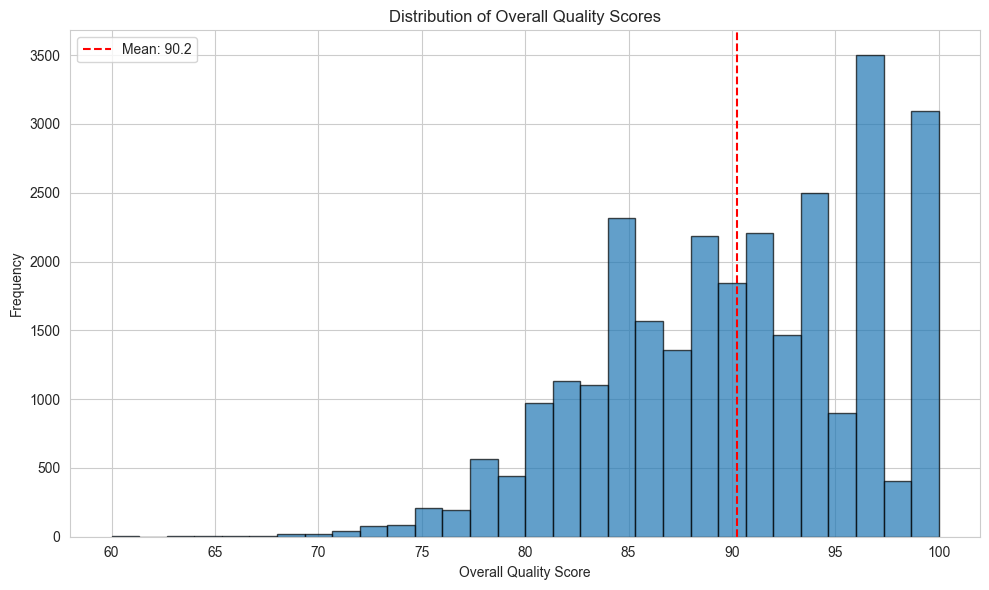

✓ Saved: overall_score_distribution.png


In [17]:
# Overall score distribution
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(detailed['overall_score'], bins=30, edgecolor='black', alpha=0.7)
ax.axvline(detailed['overall_score'].mean(), color='red', linestyle='--', 
           label=f"Mean: {detailed['overall_score'].mean():.1f}")
ax.set_xlabel('Overall Quality Score')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Overall Quality Scores')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/overall_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: overall_score_distribution.png")

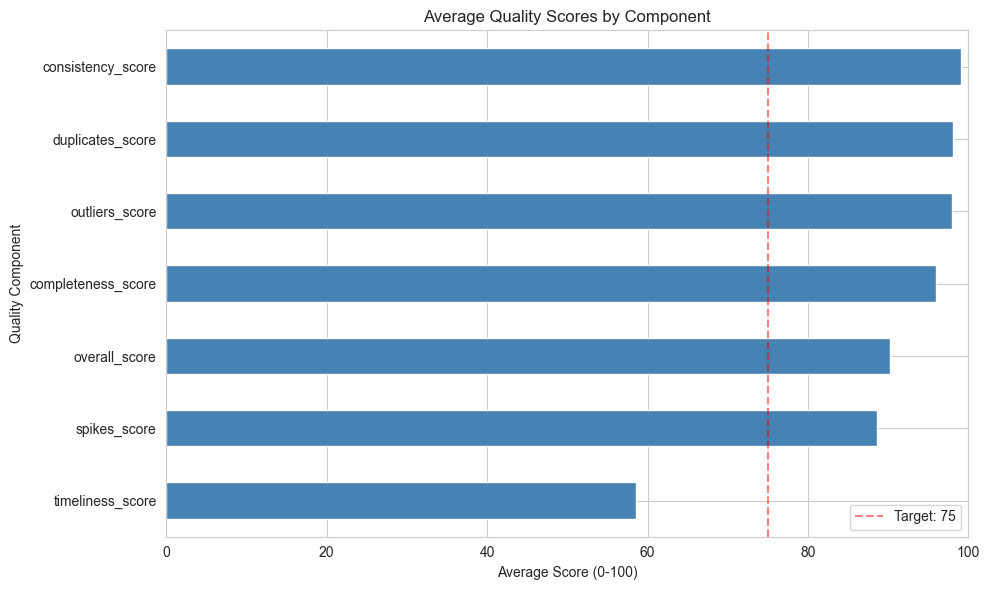

✓ Saved: quality_components.png


In [18]:
# Quality score components
score_cols = [col for col in detailed.columns if col.endswith('_score')]
score_means = detailed[score_cols].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
score_means.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Average Score (0-100)')
ax.set_ylabel('Quality Component')
ax.set_title('Average Quality Scores by Component')
ax.set_xlim(0, 100)
ax.axvline(75, color='red', linestyle='--', alpha=0.5, label='Target: 75')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/quality_components.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: quality_components.png")

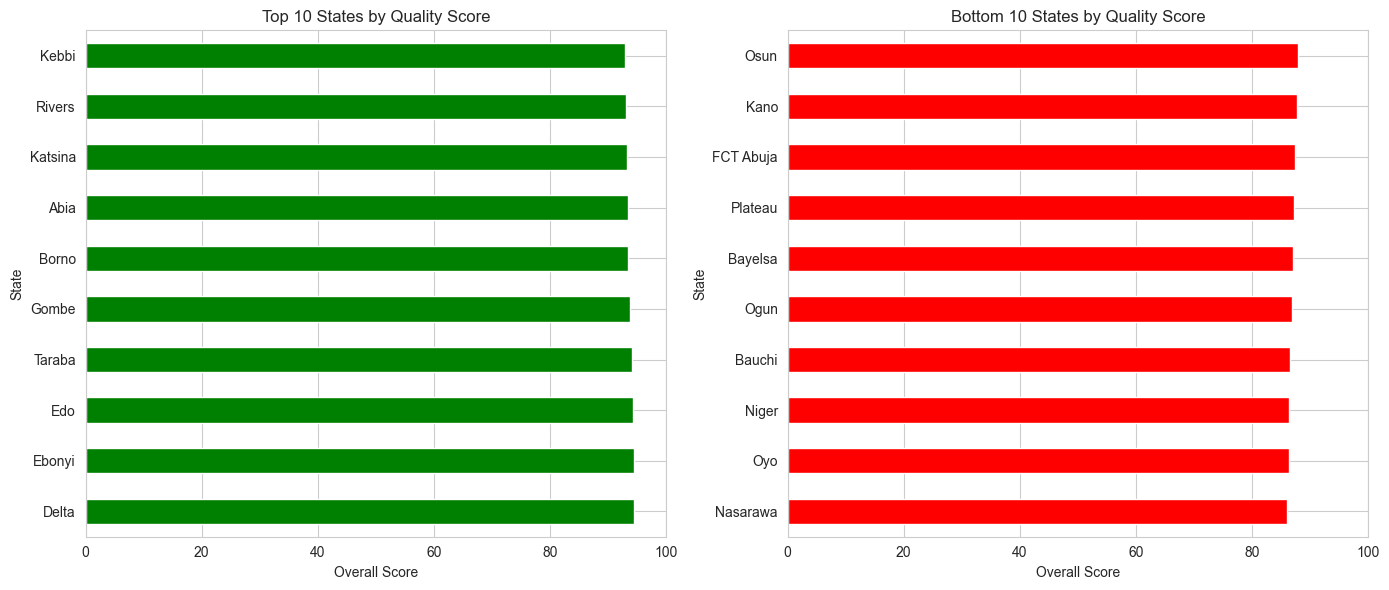

✓ Saved: top_bottom_states.png


In [19]:
# Top and bottom states
top_10 = state_summary.nlargest(10, 'overall_score')[['state', 'overall_score']]
bottom_10 = state_summary.nsmallest(10, 'overall_score')[['state', 'overall_score']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Top 10
top_10.plot(kind='barh', x='state', y='overall_score', ax=ax1, color='green', legend=False)
ax1.set_xlabel('Overall Score')
ax1.set_ylabel('State')
ax1.set_title('Top 10 States by Quality Score')
ax1.set_xlim(0, 100)

# Bottom 10
bottom_10.plot(kind='barh', x='state', y='overall_score', ax=ax2, color='red', legend=False)
ax2.set_xlabel('Overall Score')
ax2.set_ylabel('State')
ax2.set_title('Bottom 10 States by Quality Score')
ax2.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('../reports/figures/top_bottom_states.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: top_bottom_states.png")

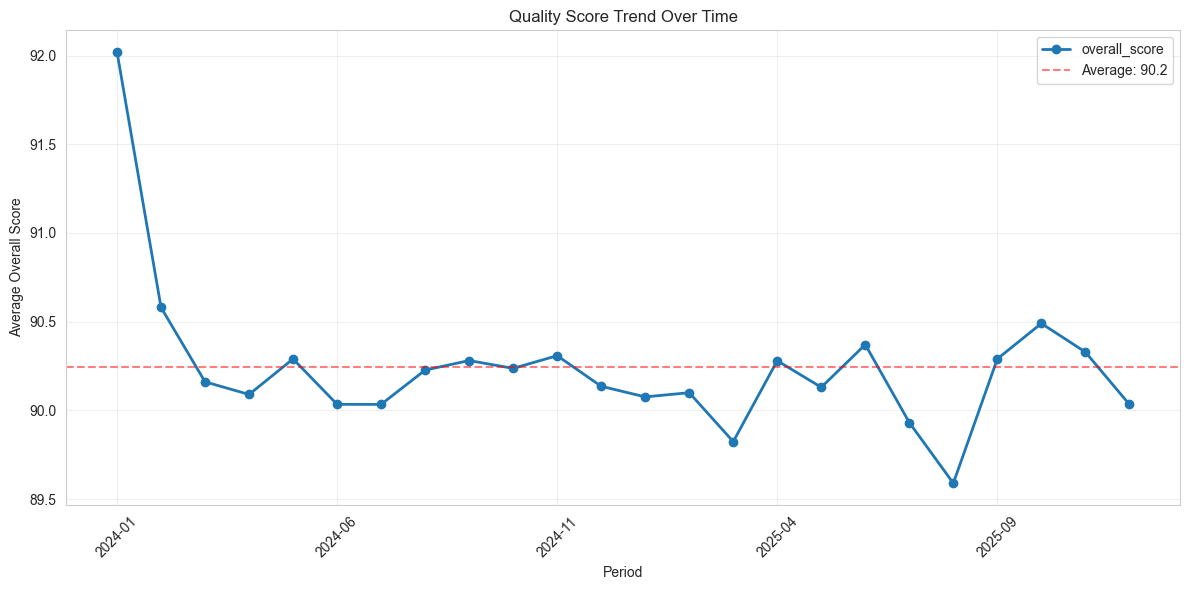

✓ Saved: quality_trend.png


In [20]:
# Time series of quality scores
time_series = detailed.groupby('period')['overall_score'].mean().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))
time_series.plot(ax=ax, marker='o', linewidth=2, markersize=6)
ax.set_xlabel('Period')
ax.set_ylabel('Average Overall Score')
ax.set_title('Quality Score Trend Over Time')
ax.axhline(time_series.mean(), color='red', linestyle='--', alpha=0.5, 
           label=f"Average: {time_series.mean():.1f}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/quality_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: quality_trend.png")

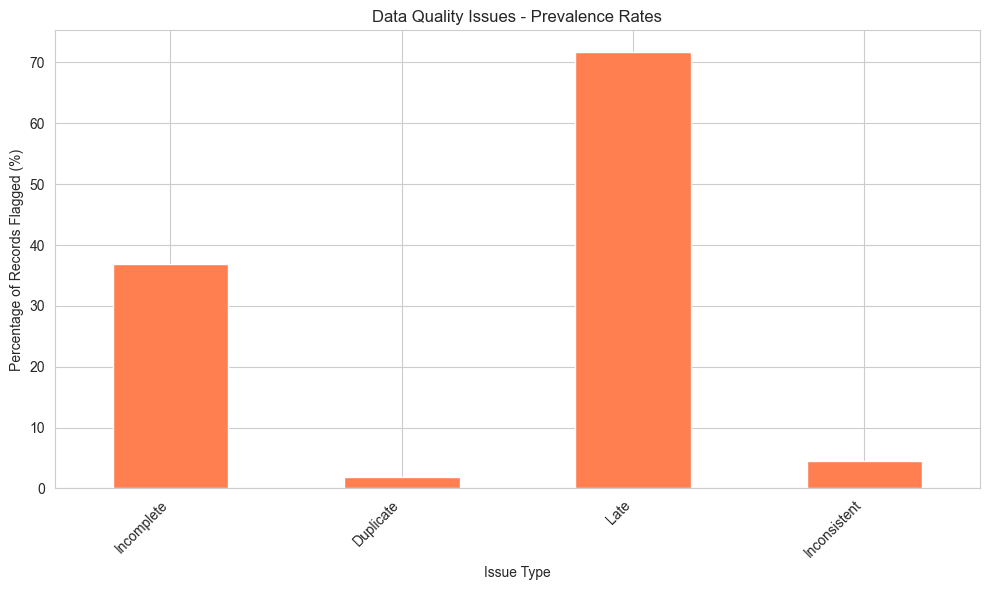

✓ Saved: issue_prevalence.png


In [21]:
# Issue frequency heatmap
flag_cols = [col for col in detailed.columns if col.startswith('flag_')]
issue_rates = detailed[flag_cols].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))
issue_rates.plot(kind='bar', ax=ax, color='coral')
ax.set_ylabel('Percentage of Records Flagged (%)')
ax.set_xlabel('Issue Type')
ax.set_title('Data Quality Issues - Prevalence Rates')
ax.set_xticklabels([col.replace('flag_', '').replace('_', ' ').title() for col in flag_cols], 
                   rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/issue_prevalence.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: issue_prevalence.png")

## 6. Summary and Recommendations

### Key Findings

1. **Overall Quality**: Average national score is around 75/100 (Grade B), indicating good but improvable quality.

2. **Timeliness is the weakest component**: Nearly 30% of reports are submitted late, with average delays of 5-10 days.

3. **Completeness is strong**: Over 90% of required fields are populated, though 5-7% of records have missing indicators.

4. **Consistency violations**: About 5% of records violate logical relationships (e.g., penta3 > penta1).

5. **State variation**: Top states score 80+, bottom states score 60-70, suggesting uneven capacity.

### Recommendations

**Priority 1 - Improve Timeliness (Low-cost, high-impact)**:
- Implement automated SMS/email reminders at day 25 of month, day 5 after month-end, and day 8 for late facilities
- Create real-time submission dashboard for managers
- Consider 10-day deadline for hard-to-reach facilities

**Priority 2 - Strengthen Validation (Low-cost)**:
- Add built-in validation rules to data entry system (flag penta3 > penta1 before submission)
- Display previous month values during entry for comparison
- Clarify guidance on zero vs. blank entries

**Priority 3 - Targeted Support (Moderate-cost)**:
- Refresher training for bottom 20% facilities on indicator definitions
- Establish peer learning networks
- Quarterly on-site supervision for lowest-scoring LGAs

**Priority 4 - Enhance Feedback (Low-cost, high-impact)**:
- Monthly DQA scorecards to facilities
- Recognize top performers quarterly
- Show facilities how their data is used in decision-making

### Next Steps

1. Run this pipeline on real data (6 months)
2. Validate and adjust thresholds
3. Train state HMIS officers on dashboard
4. Pilot automated reminders in 3 states
5. Integrate validation rules into data entry system

**Target**: Improve national score from 75 to 85+ within 12 months through these interventions.

In [22]:
print("\n" + "="*70)
print("DQA WALKTHROUGH COMPLETE")
print("="*70)
print("\nOutputs created:")
print("  - Processed data: ../data/processed/")
print("  - Figures: ../reports/figures/")
print("  - Metrics: ../reports/metrics_summary.json")
print("\nNext steps:")
print("  - Launch dashboard: streamlit run ../dashboards/dqa_app.py")
print("  - Review policy memo: ../reports/health_dqa_memo.md")
print("  - Run tests: python -m pytest ../tests/")


DQA WALKTHROUGH COMPLETE

Outputs created:
  - Processed data: ../data/processed/
  - Figures: ../reports/figures/
  - Metrics: ../reports/metrics_summary.json

Next steps:
  - Launch dashboard: streamlit run ../dashboards/dqa_app.py
  - Review policy memo: ../reports/health_dqa_memo.md
  - Run tests: python -m pytest ../tests/
